# Within-User Temporal Split for NCF (70/15/15)

**Input:** `final_baseline_df.pkl`  
**Output:** `App1_train.pkl`, `App1_val.pkl`, `App1_test.pkl`

**Important:** `final_baseline_df.pkl` has already been cleaned upstream:
- Users with exclusively 0-rated interactions are removed
- For users with >= 80% zero-rated interactions, the sequence is clipped to the most recent non-zero rating
- Users still with >= 60% zero-rated interactions after clipping are removed (7,973 users)

**Split logic:**
- All rows in `final_baseline_df.pkl` are used (no further rating filter needed)
- Sort each user's interactions chronologically by `event_time`
- Split 70 / 15 / 15 by position within each user's history
- Users with fewer than 3 interactions - all rows go to train only (excluded from val/test evaluation)

**Justification:**
Unlike leave-one-out strategy for LSTM, 70/15/15 temporal split was chosen because NCF is a pointwise interaction model, not a sequential model. Instead of predicting a new item it scores arbitrary user-item pairs. The 70/15/15 split gives the model a substantial training set to learn embeddings from, and a held-out test set with multiple interactions per user to evaluate ranking against. Leave-one-out would give NCF only one positive test interaction per user, which wastes the available evaluation signal and makes the ranking metrics noisier.

## 0. Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

SEED  = 4222
MIN_INTERACTIONS = 3
TRAIN_FRAC= 0.70
VAL_FRAC = 0.15
# test gets remaining 0.15

file_path = '/content/drive/My Drive/BT4222Project/final_updated_baseline_df.pkl'
df = pd.read_pickle(file_path)

print(f"MIN_INTERACTIONS : {MIN_INTERACTIONS}")
print(f"Split            : {TRAIN_FRAC:.0%} / {VAL_FRAC:.0%} / {1-TRAIN_FRAC-VAL_FRAC:.0%}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MIN_INTERACTIONS : 3
Split            : 70% / 15% / 15%


## 1. Load final_baseline_df

In [ ]:
print(f"Shape:{df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample row:")
print(df.head(1).T)

Shape   : (8770364, 29)
Columns : ['user_id', 'book_id', 'review_id', 'event_time', 'title', 'description', 'description_truncated', 'has_meaningful_description', 'publication_year', 'num_pages', 'language_code_collapsed', 'format_collapsed', 'is_ebook', 'authors_standardized', 'main_author_id', 'author_interactions_count_before_t', 'top_shelf_tags', 'item_text_for_embedding', 'item_semantic_embedding_static', 'item_num_pages', 'user_page_preference_before_t', 'num_pages_preference_gap', 'user_hist_interaction_count_before_t', 'days_since_user_last_interaction', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'user_author_interaction_share_before_t', 'user_hist_author_diversity_before_t', 'user_profile_embedding_similarity']

Sample row:
                                                                                        0
user_id                                                  00000377eea48021d3002730d56aca9a
book_id                                         

## 2. Type Coercions and Temporal Sort

In [ ]:
df["user_id"] = df["user_id"].astype(str)
df["book_id"] = df["book_id"].astype(str)
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

# Drop rows with no event_time (cannot place in temporal order)
n_no_time = df["event_time"].isna().sum()
if n_no_time > 0:
    print(f"Dropping {n_no_time:,} rows with null event_time")
    df = df[df["event_time"].notna()].copy()

# Sort chronologically — required for temporal split
df = df.sort_values(["user_id", "event_time"]).reset_index(drop=True)

print(f"Columns kept : {df.columns.tolist()}")
print(f"Unique users : {df['user_id'].nunique():,}")
print(f"Unique books : {df['book_id'].nunique():,}")
print(f"Total rows   : {len(df):,}")

Columns kept : ['user_id', 'book_id', 'review_id', 'event_time', 'title', 'description', 'description_truncated', 'has_meaningful_description', 'publication_year', 'num_pages', 'language_code_collapsed', 'format_collapsed', 'is_ebook', 'authors_standardized', 'main_author_id', 'author_interactions_count_before_t', 'top_shelf_tags', 'item_text_for_embedding', 'item_semantic_embedding_static', 'item_num_pages', 'user_page_preference_before_t', 'num_pages_preference_gap', 'user_hist_interaction_count_before_t', 'days_since_user_last_interaction', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'user_author_interaction_share_before_t', 'user_hist_author_diversity_before_t', 'user_profile_embedding_similarity']
Unique users : 454,189
Unique books : 123,087
Total rows   : 8,770,364


## 3. Interaction Count Distribution

Interactions per user:
count    454189.0
mean         19.3
std          82.9
min           1.0
25%           2.0
50%           5.0
75%          15.0
max       12806.0
dtype: float64

  Users with <  3 interactions: 138,669  (30.5%)
  Users with <  5 interactions: 209,909  (46.2%)
  Users with < 10 interactions: 296,021  (65.2%)
  Users with < 20 interactions: 363,797  (80.1%)


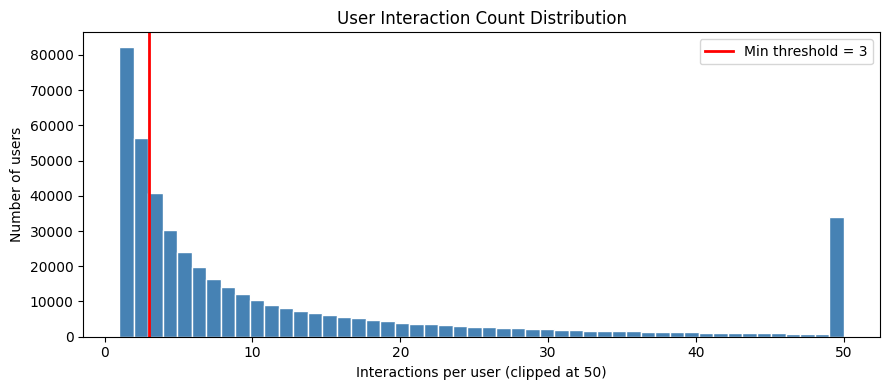

In [ ]:
user_counts = df.groupby("user_id").size()

print("Interactions per user:")
print(user_counts.describe().round(1))
print()
for t in [3, 5, 10, 20]:
    n   = (user_counts < t).sum()
    pct = (user_counts < t).mean() * 100
    print(f"  Users with < {t:2d} interactions: {n:,}  ({pct:.1f}%)")

plt.figure(figsize=(9, 4))
plt.hist(user_counts.clip(upper=50), bins=50,
         color="steelblue", edgecolor="white")
plt.axvline(MIN_INTERACTIONS, color="red", linewidth=2,
            label=f"Min threshold = {MIN_INTERACTIONS}")
plt.xlabel("Interactions per user (clipped at 50)")
plt.ylabel("Number of users")
plt.title("User Interaction Count Distribution")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Within-User Temporal Split (70/15/15)

For each user:
- **>= MIN_INTERACTIONS:** sort chronologically, split 70 / 15 / 15 by row position
- **< MIN_INTERACTIONS:** all rows go to train only - user is excluded from evaluation

All feature columns including `ncf_label` are preserved in every split.

In [ ]:
# Fast vectorized temporal split with identical split rules
g = df.groupby("user_id", sort=False)

# Per-row user history size and within-user position
n = g["user_id"].transform("size")
pos = g.cumcount()

# Per-row thresholds, matching the previous logic exactly
t = (n * TRAIN_FRAC).astype(int)
v = (n * (TRAIN_FRAC + VAL_FRAC)).astype(int)

t = np.minimum(t, n - 2)
v = np.minimum(v, n - 1)

dense_mask = n >= MIN_INTERACTIONS

is_train = (~dense_mask) | (pos < t)
is_val   = dense_mask & (pos >= t) & (pos < v)
is_test  = dense_mask & (pos >= v)

# Safety check: each row must belong to exactly one split
split_sum = is_train.astype(np.int8) + is_val.astype(np.int8) + is_test.astype(np.int8)
assert (split_sum == 1).all(), "Split assignment error: some rows are missing or duplicated"

train_df = df.loc[is_train].reset_index(drop=True)
val_df = df.loc[is_val].reset_index(drop=True)
test_df= df.loc[is_test].reset_index(drop=True)

user_sizes = g.size()
dense_users = int((user_sizes >= MIN_INTERACTIONS).sum())
sparse_users = int((user_sizes <  MIN_INTERACTIONS).sum())

print(f"Dense  users (>= {MIN_INTERACTIONS} interactions) : {dense_users:,}")
print(f"Sparse users (<  {MIN_INTERACTIONS} interactions) : {sparse_users:,}")
print()
print(f"Train : {len(train_df):>10,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):>10,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):>10,} rows  |  {test_df['user_id'].nunique():,} users")
print(f"\nAll splits have {train_df.shape[1]} columns.")

Dense  users (>= 3 interactions) : 315,520
Sparse users (<  3 interactions) : 138,669

Train :  6,017,121 rows  |  454,189 users
Val   :  1,317,799 rows  |  315,520 users
Test  :  1,435,444 rows  |  315,520 users

All splits have 29 columns.


## 5. Sanity Checks

In [ ]:
train_users = set(train_df["user_id"].unique())
val_users   = set(val_df["user_id"].unique())
test_users  = set(test_df["user_id"].unique())

assert val_users.issubset(train_users),  "Val users must appear in train"
assert test_users.issubset(train_users), "Test users must appear in train"
print(f"Val  users subset of train : {val_users.issubset(train_users)}")
print(f"Test users subset of train : {test_users.issubset(train_users)}")
print(f"Val  users : {len(val_users):,}")
print(f"Test users : {len(test_users):,}")
print(f"Users in both val and test : {len(val_users & test_users):,}")

# Temporal ordering check
print("\nChecking temporal ordering (no leakage)...")
train_max = train_df.groupby("user_id")["event_time"].max()
val_min = val_df.groupby("user_id")["event_time"].min()
test_min = test_df.groupby("user_id")["event_time"].min()

leaks_tv = (train_max[train_max.index.intersection(val_min.index)] >
            val_min[train_max.index.intersection(val_min.index)]).sum()
leaks_tt = (train_max[train_max.index.intersection(test_min.index)] >
            test_min[train_max.index.intersection(test_min.index)]).sum()
print(f"  Train-Val  leaks : {leaks_tv}  (should be 0)")
print(f"  Train-Test leaks : {leaks_tt}  (should be 0)")


# Missingness on key before_t features
print("\nMissingness on key before_t features (test split):")
key_cols = [
    "user_hist_interaction_count_before_t",
    "book_interactions_count_before_t",
    "user_author_interaction_share_before_t",
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    "days_since_user_last_interaction",
    "days_since_book_last_interaction",
]
for col in key_cols:
    if col in test_df.columns:
        pct = test_df[col].isna().mean() * 100
        print(f"  {col:50s}: {pct:.1f}% null")

Val  users subset of train : True
Test users subset of train : True
Val  users : 315,520
Test users : 315,520
Users in both val and test : 315,520

Checking temporal ordering (no leakage)...
  Train-Val  leaks : 0  (should be 0)
  Train-Test leaks : 0  (should be 0)

Missingness on key before_t features (test split):
  user_hist_interaction_count_before_t              : 0.0% null
  book_interactions_count_before_t                  : 0.0% null
  user_author_interaction_share_before_t            : 0.0% null
  num_pages_preference_gap                          : 11.1% null
  user_profile_embedding_similarity                 : 0.0% null
  days_since_user_last_interaction                  : 0.0% null
  days_since_book_last_interaction                  : 1.0% null


## 6. Save Splits

In [ ]:
train_df.to_pickle("/content/drive/My Drive/BT4222Project/App1_train.pkl")
val_df.to_pickle("/content/drive/My Drive/BT4222Project/App1_val.pkl")
test_df.to_pickle("/content/drive/My Drive/BT4222Project/App1_test.pkl")

print("Saved successfully:")
print(f"  App1_train.pkl  —  {len(train_df):,} rows  |  {train_df.shape[1]} cols")
print(f"  App1_val.pkl    —  {len(val_df):,} rows  |  {val_df.shape[1]} cols")
print(f"  App1_test.pkl   —  {len(test_df):,} rows  |  {test_df.shape[1]} cols")

Saved successfully:
  App1_train.pkl  —  6,017,121 rows  |  29 cols
  App1_val.pkl    —  1,317,799 rows  |  29 cols
  App1_test.pkl   —  1,435,444 rows  |  29 cols
